# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('delivery_dataset.csv', index_col=0)
df

,Шифр заказа (ID),Расстояние до клиента (в км),Количество позиций в чеке (в шт.),Балл пробок на дорогах (в баллах),Погода (в градусах Цельсия),Этаж доставки (в этажах),Время доставки (в минутах)
Дата заказа (ГГГГ-ММ-ДД),,,,,,,
2026-09-08,ORD-202608001,11.3,1,9,21.0,6,79.2
2026-08-29,ORD-202608002,7.3,3,7,27.0,7,46.6
2026-08-15,ORD-202608003,2.2,1,3,20.0,5,16.3
2026-08-08,ORD-202608004,0.9,2,6,22.9,1,15.8
2026-08-21,ORD-202608005,12.3,14,4,18.1,2,69.2
...,...,...,...,...,...,...,...
2026-08-12,ORD-202608496,5.2,2,3,18.0,9,28.9
2026-08-09,ORD-202608497,10.0,3,4,21.6,10,48.0
2026-08-07,ORD-202608498,5.5,3,2,9.5,3,27.0


#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих; 
* в тестовой: 100 последних.

In [2]:
feature_columns = [
    'Расстояние до клиента (в км)',
    'Количество позиций в чеке (в шт.)',
    'Балл пробок на дорогах (в баллах)',
    'Погода (в градусах Цельсия)',
    'Этаж доставки (в этажах)'
]
target_column = 'Время доставки (в минутах)'

X = df[feature_columns]
y = df[target_column]

X_train, y_train = X.iloc[:300], y.iloc[:300]
X_val, y_val = X.iloc[300:400], y.iloc[300:400]
X_test, y_test = X.iloc[400:500], y.iloc[400:500]

#### Вопрос 1. 

Для чего мы разбиваем данные на выборки? Для чего нам нужна тренировачная, для чего валидационная, для чего тестовая?

мы разбиваем данные на выборки: тренировочная - для обучения модели и подбора коэффициентов, валидационная - протестировать работу модели во время обучения, сделать вывод об обученности, недообученности, переобученности и в случае чего исправить 
тестовая- протестировать работу модели после завершения обучения для окончательной оценки качества модели

#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

In [4]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [5]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=0.0, solver='sparse_cg')
model.fit(X_train, y_train)

print('Коэффициенты:', model.coef_)
print('Свободный член:', model.intercept_)

Коэффициенты: [ 4.39612671  0.83532692  2.15389382 -0.04734781  0.34323145]
Свободный член: -2.9673282180037504


#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

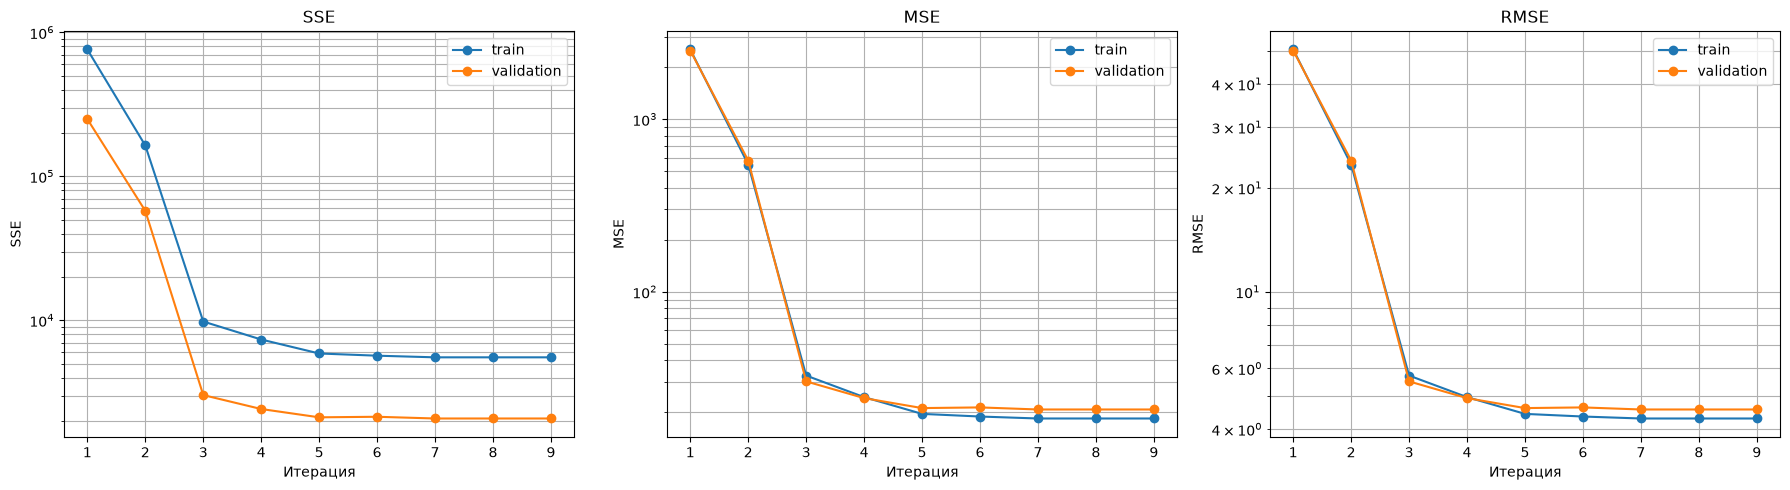

Количество итераций: 9
Финальный train RMSE: 4.2931
Финальный validation RMSE: 4.5591


In [6]:
X_train_np = X_train.to_numpy(dtype=float)
y_train_np = y_train.to_numpy(dtype=float)
X_val_np = X_val.to_numpy(dtype=float)
y_val_np = y_val.to_numpy(dtype=float)

X_train_aug = np.column_stack((np.ones(len(X_train_np)), X_train_np))
X_val_aug = np.column_stack((np.ones(len(X_val_np)), X_val_np))

A = X_train_aug.T @ X_train_aug
b = X_train_aug.T @ y_train_np

weights = np.zeros(X_train_aug.shape[1])
residual = b - A @ weights
direction = residual.copy()

max_iter = X_train_aug.shape[1] * 3
epsilon = 1e-10

train_sse, val_sse = [], []
train_mse, val_mse = [], []
train_rmse, val_rmse = [], []

for _ in range(max_iter):
    train_prediction = X_train_aug @ weights
    val_prediction = X_val_aug @ weights
    train_errors = y_train_np - train_prediction
    val_errors = y_val_np - val_prediction

    current_train_sse = np.sum(train_errors ** 2)
    current_val_sse = np.sum(val_errors ** 2)
    train_sse.append(current_train_sse)
    val_sse.append(current_val_sse)
    train_mse.append(current_train_sse / len(y_train_np))
    val_mse.append(current_val_sse / len(y_val_np))
    train_rmse.append(np.sqrt(train_mse[-1]))
    val_rmse.append(np.sqrt(val_mse[-1]))

    if np.linalg.norm(residual) < epsilon:
        break

    residual_norm_squared = residual @ residual
    step_length = residual_norm_squared / (direction @ A @ direction)
    weights = weights + step_length * direction
    new_residual = residual - step_length * (A @ direction)
    beta = (new_residual @ new_residual) / residual_norm_squared
    direction = new_residual + beta * direction
    residual = new_residual

iterations = np.arange(1, len(train_sse) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [
    (train_sse, val_sse, 'SSE'),
    (train_mse, val_mse, 'MSE'),
    (train_rmse, val_rmse, 'RMSE')
]

for axis, (train_metric, val_metric, title) in zip(axes, metrics):
    axis.plot(iterations, train_metric, marker='o', label='train')
    axis.plot(iterations, val_metric, marker='o', label='validation')
    axis.set_title(title)
    axis.set_xlabel('Итерация')
    axis.set_ylabel(title)
    axis.set_xticks(iterations)
    axis.set_yscale('log')
    axis.grid(True, which='both')
    axis.legend()

plt.tight_layout()
plt.show()

print(f'Количество итераций: {len(train_sse)}')
print(f'Финальный train RMSE: {train_rmse[-1]:.4f}')
print(f'Финальный validation RMSE: {val_rmse[-1]:.4f}')

#### Вопрос 2.

Какую информацию про нашу модель несут эти графики?

графики показывают, как изменяются ошибки модели на тренировочной и валидационной выборках с каждой итерацией обучения
SSE показывает сумму квадратов ошибок (лучше напрямую не сравнивать тк в train в 3 раза больше объектов)
MSE показывает средний квадрат ошибки на 1 объект (SSE деленный на количество)
RMSE - корень из MSE, показывает типичную ошибку предсказания в минутах

#### Вопрос 3. 

Какая траектория линий train и val ошибок будет на графиках недообученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках обученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках переобученной модели и почему?

у недообученной модели train и validation стабилизируются на высоком уровне и там и остаются (модель не может нормально описать закономерность даже на обучающих данных)

у обученной модели train и validation ошибки уменьшаются и затем стабилизируются, конечные значения близки (модель хорошо обучилась и правильно строит закономерности, ошибки уменьшаются, сохраняет качество на новых объектах; например,  у нас разница небольшая -> модель хорошо обучена)

у переобученной train строго уменшается; validation тоже, но затем вначинает расти (модель слишком хорошо подстроилась под train, на новых значениях работает хуже)

#### Шаг 6. Применение модели на тестовой выборке

In [7]:
y_predict = model.predict(X_test)

predictions_table = pd.DataFrame({
    'Код заказа (ID)': df.iloc[400:500]['Шифр заказа (ID)'].to_numpy(),
    'Предсказанное время (мин.)': y_predict,
    'Настоящее время (мин.)': y_test.to_numpy(),
})
predictions_table['Ошибка (предсказание - факт)'] = (
    predictions_table['Предсказанное время (мин.)']
    - predictions_table['Настоящее время (мин.)']
)

print(predictions_table.to_string(index=False))
predictions_table.to_csv('delivery_predictions.csv', index=False)
print('\nТаблица сохранена в delivery_predictions.csv')

Код заказа (ID)  Предсказанное время (мин.)  Настоящее время (мин.)  Ошибка (предсказание - факт)
  ORD-202608401                   33.066235                    33.9                     -0.833765
  ORD-202608402                   33.125508                    33.1                      0.025508
  ORD-202608403                   20.852183                    16.3                      4.552183
  ORD-202608404                   34.385205                    34.7                     -0.314795
  ORD-202608405                   17.562288                    13.3                      4.262288
  ORD-202608406                   42.809253                    39.3                      3.509253
  ORD-202608407                   37.448654                    36.3                      1.148654
  ORD-202608408                   12.347193                    11.9                      0.447193
  ORD-202608409                   59.054299                    56.5                      2.554299
  ORD-202608410     

#### Шаг 7. RMSE на тестовой выборке

In [8]:
test_errors = y_test.to_numpy() - y_predict
test_sse = np.sum(test_errors ** 2)
test_mse = test_sse / len(y_test)
test_rmse = np.sqrt(test_mse)

print(f'Test SSE: {test_sse:.4f}')
print(f'Test MSE: {test_mse:.4f}')
print(f'Test RMSE: {test_rmse:.4f}')

Test SSE: 2333.9835
Test MSE: 23.3398
Test RMSE: 4.8311


#### Вопрос 4.

Что получившийся RMSE может сказать о нашей модели?

RMSE показывает типичную ошибку в минутах, наш равен 4.8311 , невелик по сравнению с временем заказов, значит, для нашей задачи подходит метод линейной регрессии (если допускается ошибка в 5 минут)
наш равен 4.8311 мин -> модель в среднем ошибается на это значение
для train 4.2931, для validation 4.5591 - значения близки, переобучения нет